In [107]:
import requests
import zipfile
import os

# Step 1: Specify paths
output_dir = "C:/Users/haann/Downloads"  # Change to a writable directory
output_zip = os.path.join(output_dir, "flickr8k.zip")
extract_dir = os.path.join(output_dir, "flickr8k")

# Ensure the output directory exists
os.makedirs(output_dir, exist_ok=True)

# Step 2: Check if file is already downloaded
if not os.path.exists(output_zip) and not os.path.exists(extract_dir):
    print("Downloading Flickr8k dataset...")
    response = requests.get("https://github.com/awsaf49/flickr-dataset/releases/download/v1.0/flickr8k.zip", stream=True)
    with open(output_zip, "wb") as file:
        for chunk in response.iter_content(chunk_size=1024):
            file.write(chunk)
    print("Download completed.")
else:
    print("Dataset already downloaded. Skipping download.")

# Step 3: Extract the contents of the ZIP file (if not already extracted)
if not os.path.exists(extract_dir):
    print("Extracting dataset...")
    with zipfile.ZipFile(output_zip, "r") as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Extraction completed.")
else:
    print("Dataset already extracted. Skipping extraction.")

# Step 4: Delete the ZIP file (optional)
if os.path.exists(output_zip):
    print("Cleaning up...")
    os.remove(output_zip)

print("Downloaded Flickr8k dataset successfully.")

Dataset already downloaded. Skipping download.
Dataset already extracted. Skipping extraction.
Downloaded Flickr8k dataset successfully.


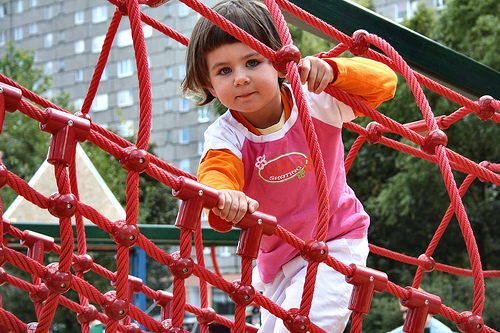

In [108]:
from PIL import Image
image = Image.open(r"C:\Users\haann\Downloads\flickr8k\Images\1007320043_627395c3d8.jpg")
display(image)

In [109]:
pip install tensorflow keras pillow

Note: you may need to restart the kernel to use updated packages.


In [110]:
from keras.applications.vgg16 import VGG16
from keras.models import Model
from keras.applications.imagenet_utils import preprocess_input
from keras.preprocessing.image import load_img, img_to_array
from os import listdir
from pickle import dump, load
import os

# Step 1: Extract features from each photo in the directory
def extract_features(directory):
    # Load the pre-trained VGG16 model
    model = VGG16()
    model.layers.pop()  # Remove the last layer to get the feature maps
    model = Model(inputs=model.inputs, outputs=model.layers[-1].output)
    print("VGG16 model loaded.")
    
    # Dictionary to store features
    features = dict()

    # Iterate through all images in the directory
    for name in listdir(directory):
        filename = os.path.join(directory, name)
        try:
            # Load and preprocess the image
            image = load_img(filename, target_size=(224, 224))
            image = img_to_array(image)
            image = image.reshape((1, image.shape[0], image.shape[1], image.shape[2]))
            image = preprocess_input(image)

            # Extract features
            feature = model.predict(image, verbose=0)
            image_id = name.split('.')[0]
            features[image_id] = feature
            print(f"Processed {name}.")
        except Exception as e:
            print(f"Error processing {name}: {e}")
    
    return features

# Step 2: Define dataset directory and check if features file exists
dataset_directory = r"C:\Users\haann\Downloads\flickr8k\Images"  # Update this path to your local dataset
output_file = os.path.join(r"C:\Users\haann\Downloads", "features.pkl")

# Check if features file exists
if os.path.exists(output_file):
    with open(output_file, 'rb') as file:
        features = load(file)
    print(f"Loaded features from {output_file}.")
else:
    features = extract_features(dataset_directory)
    # Step 3: Save the features to a pickle file
    with open(output_file, 'wb') as file:
        dump(features, file)
    print(f"Features saved to {output_file}.")


Loaded features from C:\Users\haann\Downloads\features.pkl.


In [111]:
import requests, zipfile, os

# Define the download URL and output path
url = "https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_text.zip"
output_dir = r"C:\Users\haann\Downloads\flickr8k"
zip_file = os.path.join(output_dir, "Flickr8k_text.zip")

# Ensure the output directory exists
os.makedirs(output_dir, exist_ok=True)

# Download the file
print("Downloading Flickr8k_text.zip...")
response = requests.get(url, stream=True)
with open(zip_file, "wb") as file:
    for chunk in response.iter_content(chunk_size=1024):
        file.write(chunk)
print("Download completed.")

# Extract the zip file
print("Extracting Flickr8k_text.zip...")
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(output_dir)
print("Extraction completed.")

# Remove the ZIP file (optional)
os.remove(zip_file)
print(f"Flickr8k.token.txt extracted to {output_dir}.")

Download completed.
Extracting Flickr8k_text.zip...
Extraction completed.
Flickr8k.token.txt extracted to C:\Users\haann\Downloads\flickr8k.


In [112]:
import string
import os

# Step 1: Function to locate the token file
def find_token_file(root_directory, filename="Flickr8k.token.txt"):
    for root, _, files in os.walk(root_directory):
        if filename in files:
            return os.path.join(root, filename)
    return None

# Step 2: Load a text file into memory
def load_doc(filename):
    with open(filename, 'r') as file:
        text = file.read()
    return text

# Step 3: Parse descriptions from the loaded document
def load_descriptions(doc):
    mapping = dict()
    for line in doc.split('\n'):
        tokens = line.split()
        if len(line) < 2:
            continue
        image_id, image_desc = tokens[0], tokens[1:]
        image_id = image_id.split('.')[0]
        image_desc = ' '.join(image_desc)
        if image_id not in mapping:
            mapping[image_id] = list()
        mapping[image_id].append(image_desc)
    return mapping

# Step 4: Clean descriptions
def clean_descriptions(descriptions):
    table = str.maketrans('', '', string.punctuation)
    for key, desc_list in descriptions.items():
        for i in range(len(desc_list)):
            desc = desc_list[i]
            desc = desc.split()
            desc = [word.lower() for word in desc]
            desc = [w.translate(table) for w in desc]  # Remove punctuation
            desc = [word for word in desc if len(word) > 1]  # Remove single characters
            desc = [word for word in desc if word.isalpha()]  # Remove non-alphabetic tokens
            desc_list[i] = ' '.join(desc)

# Step 5: Save cleaned descriptions to a file
def save_descriptions(descriptions, filename):
    lines = list()
    for key, desc_list in descriptions.items():
        for desc in desc_list:
            lines.append(key + ' ' + desc)
    data = '\n'.join(lines)
    with open(filename, 'w') as file:
        file.write(data)

# Step 6: Execute the processing pipeline
root_directory = r"C:\Users\haann\Downloads\flickr8k"  # Root directory of your dataset
output_file = r"C:\Users\haann\Downloads\descriptions.txt"  # Output file for cleaned descriptions

# Automatically find the token file
token_file = find_token_file(root_directory)

if token_file:
    print(f"Token file found: {token_file}")
    
    # Load and process the descriptions
    doc = load_doc(token_file)
    descriptions = load_descriptions(doc)
    print('Loaded descriptions:', len(descriptions))

    # Clean descriptions
    clean_descriptions(descriptions)

    # Save cleaned descriptions
    save_descriptions(descriptions, output_file)
    print(f"Cleaned descriptions saved to {output_file}")
else:
    print(f"Token file not found in {root_directory}. Ensure the dataset is extracted correctly.")

Token file found: C:\Users\haann\Downloads\flickr8k\Flickr8k.token.txt
Loaded descriptions: 8092
Cleaned descriptions saved to C:\Users\haann\Downloads\descriptions.txt


Loaded 8092 descriptions.


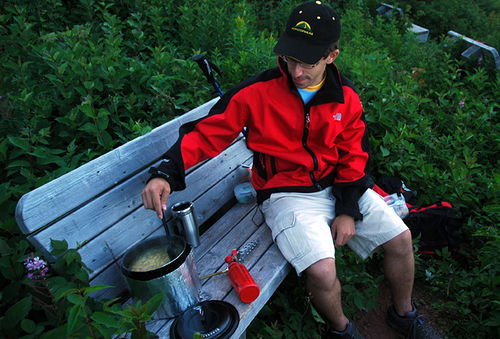

Descriptions for 35506150_cbdb630f4f:
man in red jacket is sitting on bench whilst cooking meal
man is sitting on bench cooking some food
man sits on bench
man wearing red jacket is sitting on wooden bench and is cooking something in small pot
man wearing red jacket sitting on bench next to various camping items


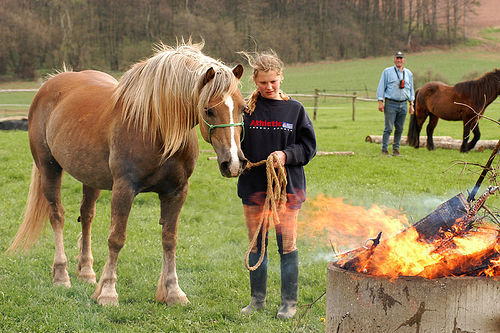

Descriptions for 10815824_2997e03d76:
blonde horse and blonde girl in black sweatshirt are staring at fire in barrel
girl and her horse stand by fire
girl holding horse lead behind fire
man and girl and two horses are near contained fire
two people and two horses watching fire


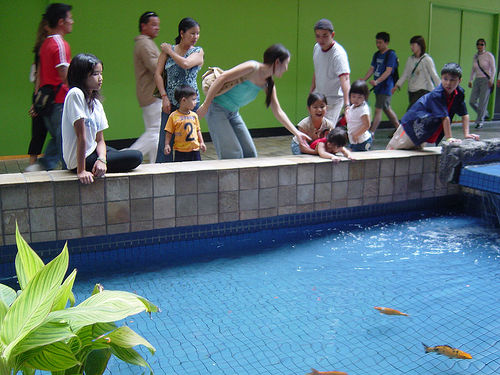

Descriptions for 12830823_87d2654e31:
children sit and watch the fish moving in the pond
people stare at the orange fish
several people are standing near fish pond
some children watching fish in pool
there are several people and children looking into water with blue tiled floor and goldfish


In [113]:
from PIL import Image
import os

# Path to your images folder and the descriptions dictionary
dataset_directory = r"C:\Users\haann\Downloads\flickr8k\Images"
descriptions_file = r"C:\Users\haann\Downloads\descriptions.txt"

# Step 1: Load the descriptions into a dictionary
def load_descriptions_from_file(filename):
    descriptions = dict()
    with open(filename, 'r') as file:
        for line in file:
            tokens = line.strip().split(' ', 1)
            if len(tokens) < 2:
                continue
            image_id, description = tokens
            if image_id not in descriptions:
                descriptions[image_id] = []
            descriptions[image_id].append(description)
    return descriptions

# Load the descriptions from the file
descriptions = load_descriptions_from_file(descriptions_file)
print(f"Loaded {len(descriptions)} descriptions.")

# Step 2: Function to display an image and its descriptions
def display_image_and_descriptions(image_id):
    image_file = os.path.join(dataset_directory, image_id + '.jpg')  # Assuming all image filenames are .jpg
    if os.path.exists(image_file):
        # Load and display the image
        image = Image.open(image_file)
        display(image)

        # Retrieve and print the descriptions for the image
        if image_id in descriptions:
            print(f"Descriptions for {image_id}:")
            print('\n'.join(descriptions[image_id]))
        else:
            print(f"No descriptions found for {image_id}")
    else:
        print(f"Image {image_id} not found.")

# Step 3: Example usage: Display image and descriptions for given image IDs
image_ids_to_display = ['35506150_cbdb630f4f', '10815824_2997e03d76', '12830823_87d2654e31']
for image_id in image_ids_to_display:
    display_image_and_descriptions(image_id)

In [114]:
from numpy import array
from pickle import load
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout
from tensorflow.keras.layers import add
from tensorflow.keras.callbacks import ModelCheckpoint


In [115]:
def load_doc(filename):
    with open(filename, 'r') as file:
        text = file.read()
    return text


In [116]:

def load_set(filename):
    doc = load_doc(filename)
    dataset = set()
    for line in doc.split('\n'):
        if len(line) < 1:
            continue
        identifier = line.split('.')[0]
        dataset.add(identifier)
    return dataset

In [117]:
def load_clean_descriptions(filename, dataset):
    doc = load_doc(filename)
    descriptions = {}
    for line in doc.split('\n'):
        tokens = line.split()
        if len(tokens) < 2:
            continue
        image_id, image_desc = tokens[0], tokens[1:]
        if image_id in dataset:
            if image_id not in descriptions:
                descriptions[image_id] = []
            desc = 'startseq ' + ' '.join(image_desc) + ' endseq'
            descriptions[image_id].append(desc)
    return descriptions


In [118]:
def load_photo_features(filename, dataset):
    all_features = load(open(filename, 'rb'))
    features = {k: all_features[k] for k in dataset}
    return features


In [119]:
def to_lines(descriptions):
    all_desc = []
    for key in descriptions.keys():
        [all_desc.append(d) for d in descriptions[key]]
    return all_desc


In [120]:
def create_tokenizer(descriptions):
    lines = to_lines(descriptions)
    tokenizer = Tokenizer()
    tokenizer.fit_on_texts(lines)
    return tokenizer


In [121]:
def max_length(descriptions):
    lines = to_lines(descriptions)
    return max(len(d.split()) for d in lines)


In [122]:
def create_sequences(tokenizer, max_length, desc_list, photo, vocab_size):
    X1, X2, y = [], [], []
    for desc in desc_list:
        seq = tokenizer.texts_to_sequences([desc])[0]
        for i in range(1, len(seq)):
            in_seq, out_seq = seq[:i], seq[i]
            in_seq = pad_sequences([in_seq], maxlen=max_length)[0]
            out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]
            X1.append(photo)
            X2.append(in_seq)
            y.append(out_seq)
    return array(X1), array(X2), array(y)


In [123]:
def define_model(vocab_size, max_length):
    # Feature extractor model
    inputs1 = Input(shape=(1000,))
    fe1 = Dropout(0.5)(inputs1)
    fe2 = Dense(256, activation='relu')(fe1)
    
    # Sequence model
    inputs2 = Input(shape=(max_length,))
    se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
    se2 = Dropout(0.5)(se1)
    se3 = LSTM(256)(se2)
    
    # Decoder model
    decoder1 = add([fe2, se3])
    decoder2 = Dense(256, activation='relu')(decoder1)
    outputs = Dense(vocab_size, activation='softmax')(decoder2)
    
    # Tie it together
    model = Model(inputs=[inputs1, inputs2], outputs=outputs)
    model.compile(loss='categorical_crossentropy', optimizer='adam')
    model.summary()
    plot_model(model, to_file='C:/Users/haann/Desktop/model.png', show_shapes=True)
    return model


In [125]:
import tensorflow as tf

def data_generator(descriptions, photos, tokenizer, max_length, vocab_size):
    while True:
        for key, desc_list in descriptions.items():
            photo = photos[key][0]
            in_img, in_seq, out_word = create_sequences(tokenizer, max_length, desc_list, photo, vocab_size)
            
            # Convert lists to TensorFlow tensors
            in_img = tf.convert_to_tensor(in_img, dtype=tf.float32)
            in_seq = tf.convert_to_tensor(in_seq, dtype=tf.int32)
            out_word = tf.convert_to_tensor(out_word, dtype=tf.float32)
            
            yield (in_img, in_seq), out_word


In [126]:
filename = r'C:\Users\haann\Downloads\flickr8k\Flickr_8k.trainImages.txt'
train = load_set(filename)
print(f"Dataset: {len(train)}")

train_descriptions = load_clean_descriptions(r'C:\Users\haann\Downloads\descriptions.txt', train)
train_features = load_photo_features(r'C:\Users\haann\Downloads\features.pkl', train)

tokenizer = create_tokenizer(train_descriptions)
vocab_size = len(tokenizer.word_index) + 1
max_len = max_length(train_descriptions)


Dataset: 6000


In [127]:
model = define_model(vocab_size, max_len)


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 34)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_6       │ (None, 1000)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 34, 256)   │  1,940,224 │ input_layer_7[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 1000)      │          0 │ input_layer_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 34, 256)   │          0 │ embedding_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_9         │ (None, 34)        │          0 │ input_layer_7[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 256)       │    256,256 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 256)       │    525,312 │ dropout_7[0][0],  │
│                     │                   │            │ not_equal_9[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 256)       │          0 │ dense_10[0][0],   │
│                     │                   │            │ lstm_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 256)       │     65,792 │ add_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 7579)      │  1,947,803 │ dense_11[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,735,387 (18.06 MB)

 Trainable params: 4,735,387 (18.06 MB)

 Non-trainable params: 0 (0.00 B)

In [128]:

# Train with the generator
epochs = 20
steps = len(train_descriptions)
save_on_last_epoch = True  # Change this to False to skip saving

for i in range(epochs):
    generator = data_generator(train_descriptions, train_features, tokenizer, max_len, vocab_size)
    model.fit(generator, epochs=1, steps_per_epoch=steps, verbose=1)
    
    # Save only at the end of training
    if save_on_last_epoch and i == epochs - 1:
        model.save(f'model_final_epoch_{i+1}.keras')
        print(f"Model saved after final epoch {i+1}")


6000/6000 ━━━━━━━━━━━━━━━━━━━━ 1094s 182ms/step - loss: 5.0859
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 977s 163ms/step - loss: 3.8808
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 948s 158ms/step - loss: 3.5530
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 995s 166ms/step - loss: 3.3494
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 1003s 167ms/step - loss: 3.2039
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 977s 163ms/step - loss: 3.0950
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 1066s 178ms/step - loss: 3.0125
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 1098s 183ms/step - loss: 2.9391
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 1117s 186ms/step - loss: 2.8864
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 1124s 187ms/step - loss: 2.8322
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 1126s 188ms/step - loss: 2.7926
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 1135s 189ms/step - loss: 2.7561
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 1162s 194ms/step - loss: 2.7308
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 1165s 194ms/step - loss: 2.7038
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 1280s 213ms/step - loss: 2.6838
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 1200s 200ms/step - loss: 2.6

In [163]:
print("Current working directory:", os.getcwd())



Current working directory: c:\Users\haann\Downloads\Dl_based_image_captioning_system


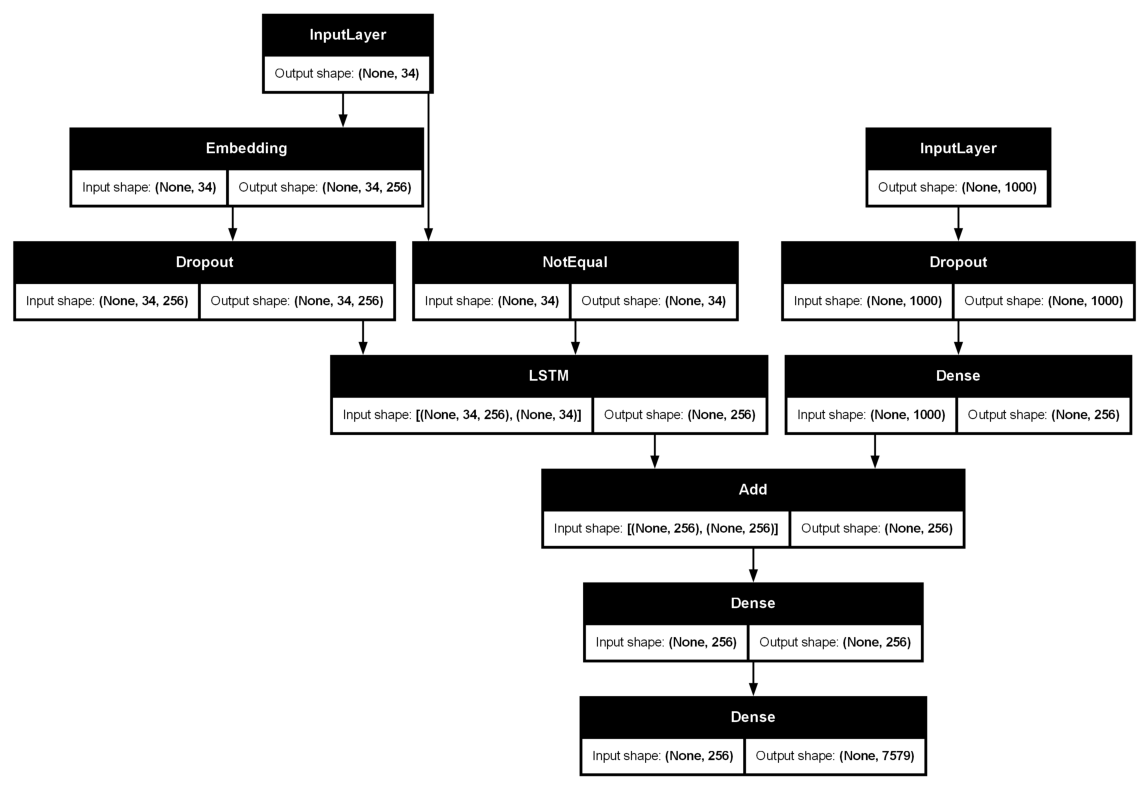

In [148]:
image_path = r"C:\Users\haann\Desktop\model.png"
image = Image.open(image_path)

# Adjust figure size for larger display
plt.figure(figsize=(25, 10))  # Adjust the size (width, height) as needed
plt.imshow(image)
plt.axis('off')  # Hide axes for better visualization
plt.show()

In [149]:
print(train_features['2513260012_03d33305cf'].shape)

(1, 1000)


In [150]:
import pickle
tokenizer_path = r"C:\Users\haann\Desktop\tokenizer.pkl"  # Path to save the tokenizer

# Save the tokenizer to the specified file
with open(tokenizer_path, 'wb') as file:
    pickle.dump(tokenizer, file)

print(f"Tokenizer saved successfully to {tokenizer_path}")

Tokenizer saved successfully to C:\Users\haann\Desktop\tokenizer.pkl


In [151]:
def word_for_id(integer, tokenizer):
    # Iterates over the tokenizer's word index to find the word for the given integer
    for word, index in tokenizer.word_index.items():
        if index == integer:
            return word
    return None

def generate_desc(model, tokenizer, photo, max_length):
    """
    Generate a description for an image using the trained model and tokenizer.

    Parameters:
    - model: The trained model for caption generation.
    - tokenizer: The tokenizer used for text processing.
    - photo: The processed photo feature vector.
    - max_length: The maximum length of the description.

    Returns:
    - in_text: The generated description as a string.
    """
    in_text = 'startseq'
    for i in range(max_length):
        # Convert the current text to a sequence of integers
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        # Pad the sequence to the required max length
        sequence = pad_sequences([sequence], maxlen=max_length)
        # Predict the next word
        yhat = model.predict([photo, sequence], verbose=0)
        # Get the index of the word with the highest probability
        yhat = np.argmax(yhat)
        # Find the corresponding word
        word = word_for_id(yhat, tokenizer)
        # If no word is found, break the loop
        if word is None:
            break
        # Append the word to the description
        in_text += ' ' + word
        # If the word is 'endseq', stop the generation
        if word == 'endseq':
            break
    return in_text

In [162]:
from pickle import load

# Load the tokenizer
tokenizer_path = r"C:\Users\haann\Desktop\tokenizer.pkl"
with open(tokenizer_path, 'rb') as file:
    tokenizer = load(file)

